In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df_januari = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-01-01 - 2024-01-31 - 15m - bewerkt.xlsx')
df_januari.head()

,Date (van),Date (tot),Unnamed: 2,Transfo 1600 kva [kW],Transfo 1000kva [kW],Zonnepark grond [kW],Zonnepark Dak [kW],Consumption [kW],Always on [kW],A.23 (extrusie lijn 9) [kW],...,A.6 (pompen koelwater/ stofafzuiging) [kW],Production [kW],Zonnepark grond [kW].1,Zonnepark Dak [kW].1,A.22 (extrusie lijn 8) [kW],A.1.19.1 (drycooler + pompen) [kW],A.1.1.1.3 (folie verpakkings lijn) [kW],A.1.1.14.1.2 (compressor 37kW) [kW],A.1.1.14.1.3 (compressor 22kW) [kW],A.1.1.14.1.1 (compressor drogers) [kW]
0,2024-01-01 00:00:00,2024-01-01 00:00:00,NaN,0.4212,49.1448,-0.1072,-0.108,49.45774,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 00:15:00,2024-01-01 00:15:00,NaN,0.4212,49.1448,-0.1072,-0.108,49.45774,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 00:30:00,2024-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 00:45:00,2024-01-01 00:45:00,NaN,0.4212,49.1448,-0.1072,-0.108,49.45774,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 01:00:00,01/01/2024 01:00,0.0,0.4212,49.1448,-0.1072,-0.108,49.45774,292.731,0.6976,...,0.6872,-0.214936,-0.1072,-0.108,3.5,0.0728,0.0024,0.0252,5.7128,1.9256


In [91]:
#maak 1 date kolom aan in df_januari
df_januari['Date'] = pd.to_datetime(df_januari[' Date (tot)'], errors='coerce', dayfirst=True)

#verwijder alle kollomen behalve date en productie
df_januari = df_januari[['Date', 'Production [kW]']].copy()
df_januari.rename(columns={'Production [kW]': 'productie'}, inplace=True)

df_januari.head()

,Date,productie
0,2024-01-01 00:00:00,NaN
1,2024-01-01 00:15:00,NaN
2,2024-01-01 00:30:00,NaN
3,2024-01-01 00:45:00,NaN
4,2024-01-01 01:00:00,-0.214936


In [92]:
#vull null waarden in productie met de volgende beschikbare waarde
df_januari['productie'] = df_januari['productie'].interpolate().bfill().ffill()

df_januari.head()

,Date,productie
0,2024-01-01 00:00:00,-0.214936
1,2024-01-01 00:15:00,-0.214936
2,2024-01-01 00:30:00,-0.214936
3,2024-01-01 00:45:00,-0.214936
4,2024-01-01 01:00:00,-0.214936


In [93]:
df_januari.isnull().sum()

Date         0
productie    0
dtype: int64

In [94]:
#check voor dubbele datums in df_januari
df_januari.duplicated(subset=['Date']).sum()

np.int64(0)

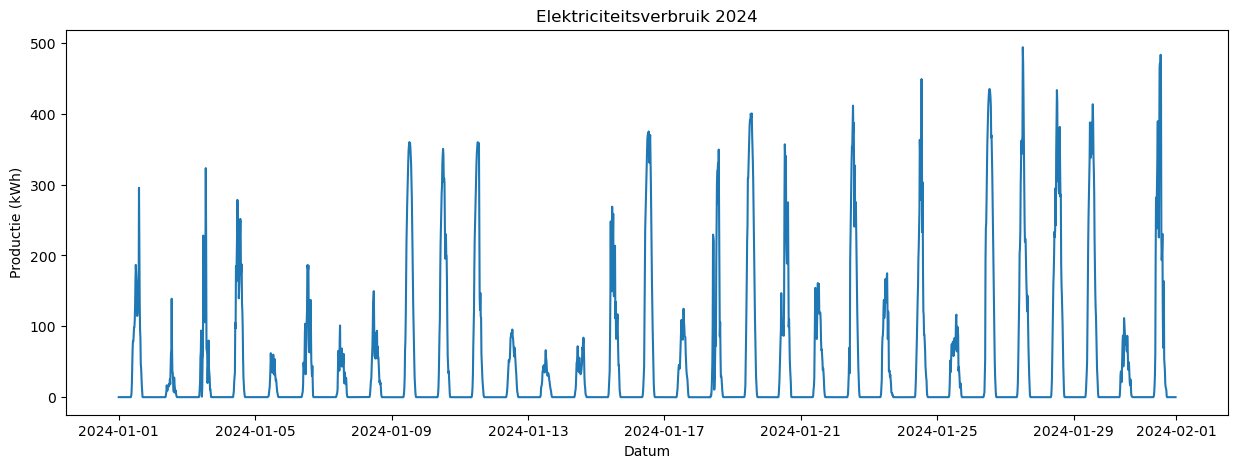

In [80]:
#plot data

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_januari, x='Date', y='productie')
plt.title('Elektriciteitsverbruik 2024')
plt.xlabel('Datum')
plt.ylabel('Productie (kWh)')
plt.show()


In [95]:
df_februari = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-02-01 - 2024-02-29 - 15m.xlsx')
df_februari.head()

,Date,Consumption [kW],Always on [kW],A.23 (extrusie lijn 9) [kW],A.9 (verdeelbord HAL J -academie) [kW],A.8 (extrusie lijn 3) [kW],A.7 (extrusie lijn 2) [kW],A.27 (compressie koelgroep) [kW],A.26 (extrusie lijn 10) [kW],A.25 (extrusie lijn6) [kW],...,A.6 (pompen koelwater/ stofafzuiging) [kW],Production [kW],Zonnepark grond [kW],Zonnepark Dak [kW],A.22 (extrusie lijn 8) [kW],A.1.19.1 (drycooler + pompen) [kW],A.1.1.1.3 (folie verpakkings lijn) [kW],A.1.1.14.1.2 (compressor 37kW) [kW],A.1.1.14.1.3 (compressor 22kW) [kW],A.1.1.14.1.1 (compressor drogers) [kW]
0,2024-02-01 01:00:00,314.507092,292.731,0.9696,0.0148,19.0032,33.7636,9.6296,0.9652,0.7460,...,28.5068,-0.249328,-0.1396,-0.1104,8.2452,3.8948,0.0024,0.0252,18.9940,2.0928
1,2024-02-01 01:15:00,301.778132,292.731,0.9692,0.0144,18.9648,33.8256,10.8988,0.9652,0.7452,...,29.2944,-0.250784,-0.1416,-0.1100,8.2664,3.9212,0.0024,0.0252,19.7984,2.0652
2,2024-02-01 01:30:00,337.739544,292.731,0.9704,0.0160,18.9624,33.7000,16.1744,0.9664,0.7460,...,28.2328,-0.250472,-0.1404,-0.1104,8.2600,3.8988,0.0024,0.0252,25.1764,2.0944
3,2024-02-01 01:45:00,350.472292,292.731,0.9716,0.0160,19.0072,33.9716,9.9416,0.9636,0.7492,...,28.6568,-0.251860,-0.1412,-0.1104,8.2288,3.9456,0.0024,0.0252,28.4496,2.1524
4,2024-02-01 02:00:00,361.723028,292.731,0.9716,0.0160,19.0020,33.9288,9.9408,0.9636,0.7492,...,27.8392,-0.252328,-0.1416,-0.1104,8.3004,3.9972,0.0024,0.0260,25.6308,2.1592


In [96]:
#verwijder alle kollomen behalve date en productie
df_februari = df_februari[['Date', 'Production [kW]']].copy()
df_februari.rename(columns={'Production [kW]': 'productie'}, inplace=True)

In [97]:
df_februari.isnull().sum()


Date         0
productie    0
dtype: int64

In [98]:
df_februari.head()

,Date,productie
0,2024-02-01 01:00:00,-0.249328
1,2024-02-01 01:15:00,-0.250784
2,2024-02-01 01:30:00,-0.250472
3,2024-02-01 01:45:00,-0.251860
4,2024-02-01 02:00:00,-0.252328


In [99]:
#check voor dubbele datums in df_februari
df_februari.duplicated(subset=['Date']).sum()

np.int64(0)

In [100]:
# Voeg januari en februari samen
df_2024 = pd.concat([df_januari, df_februari], ignore_index=True)

# Zet Date om naar datetime
df_2024['Date'] = pd.to_datetime(df_2024['Date'])

# Sorteer op datum
df_2024 = df_2024.sort_values('Date').reset_index(drop=True)

# Toon resultaat
df_2024.head()

,Date,productie
0,2024-01-01 00:00:00,-0.214936
1,2024-01-01 00:15:00,-0.214936
2,2024-01-01 00:30:00,-0.214936
3,2024-01-01 00:45:00,-0.214936
4,2024-01-01 01:00:00,-0.214936


In [101]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

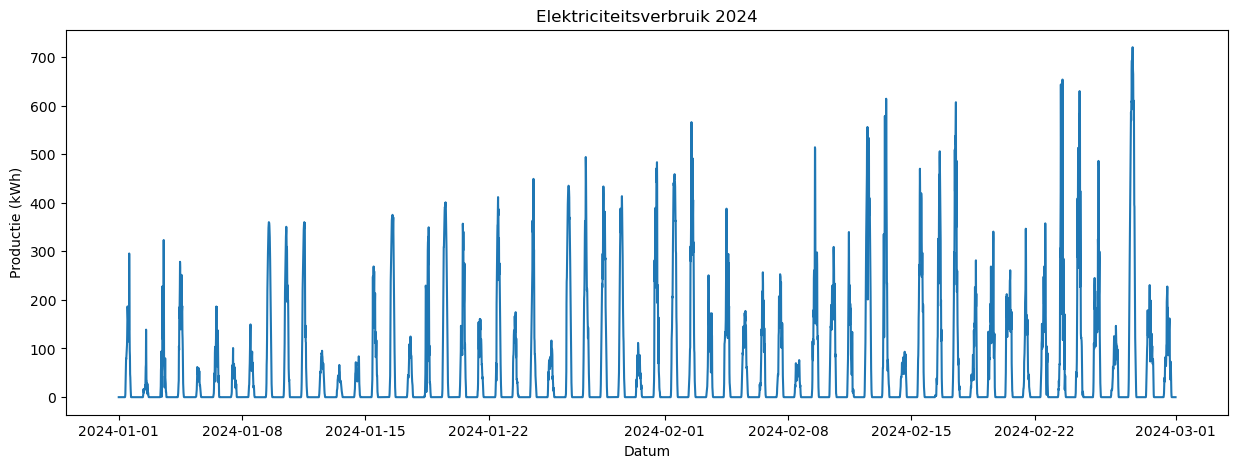

In [86]:
#plot data

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_2024, x='Date', y='productie')
plt.title('Elektriciteitsverbruik 2024')
plt.xlabel('Datum')
plt.ylabel('Productie (kWh)')
plt.show()


In [102]:
df_maart = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-03-01 - 2024-03-31 - 15m.xlsx')
df_maart['Date'] = pd.to_datetime(df_maart['Date'])

#verwijder alle kollomen behalve date en productie
df_maart = df_maart[['Date', 'Production [kW]']].copy()
df_maart.rename(columns={'Production [kW]': 'productie'}, inplace=True)
df_maart.head()


,Date,productie
0,2024-03-01 01:00:00,-0.223520
1,2024-03-01 01:15:00,-0.223480
2,2024-03-01 01:30:00,-0.220228
3,2024-03-01 01:45:00,-0.220244
4,2024-03-01 02:00:00,-0.219296


In [103]:
df_maart.isnull().sum()

Date         0
productie    0
dtype: int64

In [104]:
#voeg maart toe aan df_2024
df_2024 = pd.concat([df_2024, df_maart], ignore_index=True)


In [105]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [106]:
df_april = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-04-01 - 2024-04-30 - 15m.xlsx')
df_april['Date'] = pd.to_datetime(df_april['Date'])

df_april = df_april[['Date', 'Production [kW]']].copy()
df_april.rename(columns={'Production [kW]': 'productie'}, inplace=True)

df_april.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_april], ignore_index=True)


In [107]:
df_2024.isnull().sum()


Date         0
productie    0
dtype: int64

In [108]:
#check voor dubbele datums in df_2024
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [109]:
df_mei = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-05-01 - 2024-05-31 - 15m.xlsx')
df_mei['Date'] = pd.to_datetime(df_mei['Datum'])

df_mei = df_mei[['Date', 'Productie [kW]']].copy()
df_mei.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_mei.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_mei], ignore_index=True)


In [110]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [111]:
df_juni = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-06-01 - 2024-06-30 - 15m.xlsx')
df_juni['Date'] = pd.to_datetime(df_juni['Datum'])

df_juni = df_juni[['Date', 'Productie [kW]']].copy()
df_juni.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_juni.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_juni], ignore_index=True)


In [112]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [113]:
df_2024.isnull().sum()


Date         0
productie    0
dtype: int64

In [114]:
df_juli = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-07-01 - 2024-07-31 - 15m.xlsx')
df_juli['Date'] = pd.to_datetime(df_juli['Datum'])

df_juli = df_juli[['Date', 'Productie [kW]']].copy()
df_juli.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_juli.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_juli], ignore_index=True)


In [115]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [116]:
df_augustus = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-08-01 - 2024-08-31 - 15m.xlsx')
df_augustus['Date'] = pd.to_datetime(df_augustus['Datum'])

df_augustus = df_augustus[['Date', 'Productie [kW]']].copy()
df_augustus.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_augustus.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_augustus], ignore_index=True)


In [117]:
#check voor dubbele datums in df_2024
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [118]:
df_september = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-09-01 - 2024-09-30 - 15m.xlsx')
df_september['Date'] = pd.to_datetime(df_september['Datum'])

df_september = df_september[['Date', 'Productie [kW]']].copy()
df_september.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_september.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_september], ignore_index=True)


In [119]:
df_september.duplicated(subset=['Date']).sum()

np.int64(0)

In [120]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [121]:
df_oktober = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-10-01 - 2024-10-31 - 15m.xlsx')
df_oktober['Date'] = pd.to_datetime(df_oktober['Datum'])

df_oktober = df_oktober[['Date', 'Productie [kW]']].copy()
df_oktober.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_oktober.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_oktober], ignore_index=True)


In [122]:
df_oktober.duplicated(subset=['Date']).sum()

np.int64(4)

In [123]:
df_2024 = df_2024.drop_duplicates(subset=['Date'], keep='first')

In [124]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [125]:
# Lees het Excelbestand van november 2024 in
df_november = pd.read_excel(
    'data/Data 2024/electricity verbruik totaal alles - 2024-11-01 - 2024-11-30 - 15m.xlsx'
)

# Zet de kolom 'Datum' om naar datetime-formaat
df_november['Date'] = pd.to_datetime(df_november['Datum'])

# Tel de productie van het zonnepark op de grond en het dak samen
df_november['Productie [kW]'] = (
    df_november['Zonnepark grond [kW]'] +
    df_november['Zonnepark Dak [kW]']
)

# Behoud enkel de datum en totale productie
df_november = df_november[['Date', 'Productie [kW]']].copy()

# Hernoem de productie-kolom naar een eenvoudigere naam
df_november.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

# Controleer op ontbrekende waarden
df_november.isnull().sum()

# Voeg november toe aan de bestaande dataset van 2024
df_2024 = pd.concat([df_2024, df_november], ignore_index=True)

In [126]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [127]:
df_december = pd.read_excel('data/Data 2024/electricity verbruik totaal alles - 2024-12-01 - 2024-12-31 - 15m.xlsx')
df_december['Date'] = pd.to_datetime(df_december['Datum'])

df_december = df_december[['Date', 'Productie [kW]']].copy()
df_december.rename(columns={'Productie [kW]': 'productie'}, inplace=True)

df_december.isnull().sum()

#voeg maand toe aan df_2024
df_2024 = pd.concat([df_2024, df_december], ignore_index=True)


In [128]:
#check voor dubbele datums in df_februari
df_2024.duplicated(subset=['Date']).sum()

np.int64(0)

In [129]:
df_2024 = df_2024.drop_duplicates(subset=['Date'], keep='first')

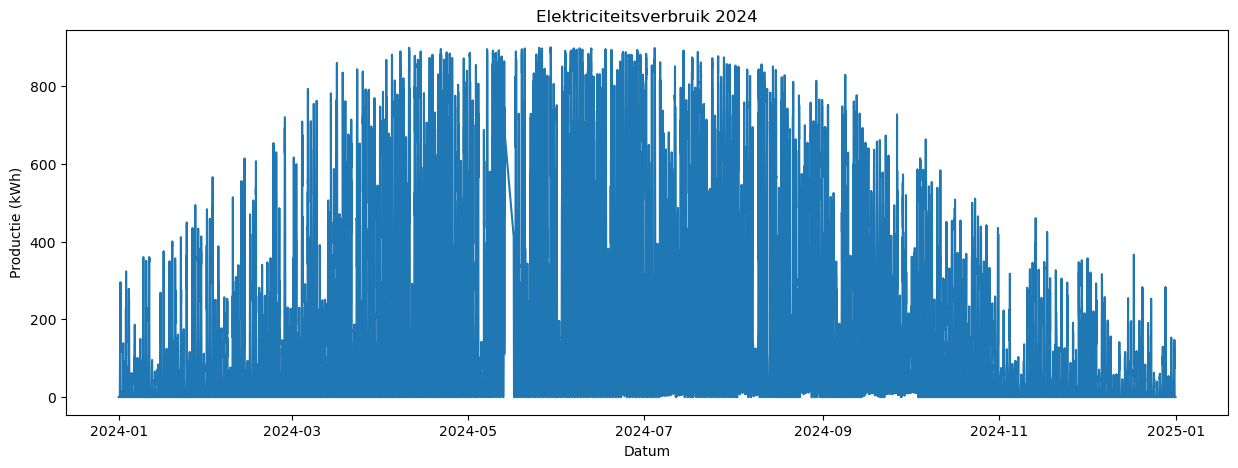

In [ ]:
#plot data

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_2024, x='Date', y='productie')
plt.title('Elektriciteitsproductie 2024')
plt.xlabel('Datum')
plt.ylabel('Productie (kWh)')
plt.show()


In [131]:
df_2024.head()

,Date,productie
0,2024-01-01 00:00:00,-0.214936
1,2024-01-01 00:15:00,-0.214936
2,2024-01-01 00:30:00,-0.214936
3,2024-01-01 00:45:00,-0.214936
4,2024-01-01 01:00:00,-0.214936


In [132]:
full_range = pd.date_range(
    start=df_2024['Date'].min(),
    end=df_2024['Date'].max(),
    freq='15T'
)

missing = full_range.difference(df_2024['Date'])

print("Missing intervals:", len(missing))

Missing intervals: 650


C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\3579252337.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_range = pd.date_range(


In [133]:
print(missing)

DatetimeIndex(['2024-02-01 00:00:00', '2024-02-01 00:15:00',
               '2024-02-01 00:30:00', '2024-02-01 00:45:00',
               '2024-02-01 12:30:00', '2024-02-02 04:30:00',
               '2024-02-02 16:30:00', '2024-02-02 20:30:00',
               '2024-02-03 08:45:00', '2024-02-03 12:45:00',
               ...
               '2024-05-16 16:45:00', '2024-05-16 17:00:00',
               '2024-05-16 17:15:00', '2024-05-16 17:30:00',
               '2024-05-16 17:45:00', '2024-05-16 18:00:00',
               '2024-05-16 18:15:00', '2024-05-16 18:30:00',
               '2024-05-17 14:30:00', '2024-09-05 02:45:00'],
              dtype='datetime64[ns]', length=650, freq=None)


In [134]:
df_2024 = df_2024.set_index('Date').asfreq('15min')
df_2024 = df_2024.interpolate().reset_index()

In [135]:
full_range = pd.date_range(
    start=df_2024['Date'].min(),
    end=df_2024['Date'].max(),
    freq='15T'
)

missing = full_range.difference(df_2024['Date'])

print("Missing intervals:", len(missing))

Missing intervals: 0


C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\3579252337.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_range = pd.date_range(


In [136]:
df_2024.to_excel('productie_2024.xlsx', index=False)

In [83]:
#download df_2024 als excel bestand
df_verbruik = pd.read_excel('energie_orac_2024.xlsx')
df_verbruik.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,-0.053734
1,2024-01-01 00:15:00,10.625,0.0,-0.053734
2,2024-01-01 00:30:00,11.875,0.0,-0.053734
3,2024-01-01 00:45:00,13.750,0.0,-0.053734
4,2024-01-01 01:00:00,14.375,0.0,-0.053734


In [ ]:
#check voor dubbele datums in df_verbruik
df_verbruik.duplicated(subset=['datetime']).sum()

np.int64(12)

In [86]:
df_verbruik = df_verbruik.drop_duplicates(subset=['datetime'], keep='first')

In [87]:
#vervang productie in df_verbruik met productie in df_2024
df_verbruik['productie_kwh'] = df_2024['productie'] * 0.25
df_verbruik.head()

C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\86954508.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_verbruik['productie_kwh'] = df_2024['productie'] * 0.25


,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,-0.053734
1,2024-01-01 00:15:00,10.625,0.0,-0.053734
2,2024-01-01 00:30:00,11.875,0.0,-0.053734
3,2024-01-01 00:45:00,13.750,0.0,-0.053734
4,2024-01-01 01:00:00,14.375,0.0,-0.053734


In [88]:
#download df_2024 als excel bestand
df_verbruik.to_excel('energie_orac_2024.xlsx', index=False)


In [6]:
df_injectie = pd.read_csv('data/Yuso-quarter-hour-injection-2024.csv', sep=';')
df_injectie.head()

,EAN,Datum en tijdstip (UTC),Datum en tijdstip (Europa/Brussel),Energie (kWh)
0,EAN541448860008243540,2023-12-31 23:00:00,2024-01-01 00:00:00,0.0
1,EAN541448860008243540,2023-12-31 23:15:00,2024-01-01 00:15:00,0.0
2,EAN541448860008243540,2023-12-31 23:30:00,2024-01-01 00:30:00,0.0
3,EAN541448860008243540,2023-12-31 23:45:00,2024-01-01 00:45:00,0.0
4,EAN541448860008243540,2024-01-01 00:00:00,2024-01-01 01:00:00,0.0


In [3]:
df_injectie_2025 = pd.read_csv('data/Yuso-quarter-hour-injection-report-Solux-Invest BV-878166437-202510231630.csv', sep=';')
df_injectie_2025.head()

,EAN,Datum en tijdstip (UTC),Datum en tijdstip (Europa/Brussel),Energie (kWh)
0,EAN541448860008243540,1/01/2025 0:00,1/01/2025 1:00,0
1,EAN541448860008243540,1/01/2025 0:15,1/01/2025 1:15,0
2,EAN541448860008243540,1/01/2025 0:30,1/01/2025 1:30,0
3,EAN541448860008243540,1/01/2025 0:45,1/01/2025 1:45,0
4,EAN541448860008243540,1/01/2025 1:00,1/01/2025 2:00,0


In [7]:
#verwijder EAN	Datum en tijdstip (UTC)
df_injectie = df_injectie.drop(columns=['EAN', 'Datum en tijdstip (UTC)'])
df_injectie.head()

,Datum en tijdstip (Europa/Brussel),Energie (kWh)
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:15:00,0.0
2,2024-01-01 00:30:00,0.0
3,2024-01-01 00:45:00,0.0
4,2024-01-01 01:00:00,0.0


In [5]:
#verwijder EAN	Datum en tijdstip (UTC)
df_injectie_2025 = df_injectie_2025.drop(columns=['EAN', 'Datum en tijdstip (UTC)'])
df_injectie_2025.head()

,Datum en tijdstip (Europa/Brussel),Energie (kWh)
0,1/01/2025 1:00,0
1,1/01/2025 1:15,0
2,1/01/2025 1:30,0
3,1/01/2025 1:45,0
4,1/01/2025 2:00,0


In [9]:
#rename kolommen
df_injectie.rename(columns={'Datum en tijdstip (Europa/Brussel)': 'Date'}, inplace=True)
df_injectie.head()

,Date,Energie (kWh)
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:15:00,0.0
2,2024-01-01 00:30:00,0.0
3,2024-01-01 00:45:00,0.0
4,2024-01-01 01:00:00,0.0


In [6]:
#rename kolommen
df_injectie_2025.rename(columns={'Datum en tijdstip (Europa/Brussel)': 'Date'}, inplace=True)
df_injectie_2025.head()

,Date,Energie (kWh)
0,1/01/2025 1:00,0
1,1/01/2025 1:15,0
2,1/01/2025 1:30,0
3,1/01/2025 1:45,0
4,1/01/2025 2:00,0


In [11]:
#rond af 2 decimalen
df_injectie['Energie (kWh)'] = df_injectie['Energie (kWh)'].round(2)

In [8]:
df_injectie_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28312 entries, 0 to 28311
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           28312 non-null  object
 1   Energie (kWh)  28312 non-null  object
dtypes: object(2)
memory usage: 442.5+ KB


In [9]:
#zet date naar datetime & energie (kwh) naar float
df_injectie_2025['Date'] = pd.to_datetime(df_injectie_2025['Date'], errors='coerce', dayfirst=True)
df_injectie_2025['Energie (kWh)'] = pd.to_numeric(df_injectie_2025['Energie (kWh)'], errors='coerce')

In [10]:
#rond af 2 decimalen
df_injectie_2025['Energie (kWh)'] = df_injectie_2025['Energie (kWh)'].round(2)

In [14]:
df_injectie.isnull().sum()

Date             0
Energie (kWh)    0
dtype: int64

In [11]:
df_injectie_2025.isnull().sum()

Date               0
Energie (kWh)    899
dtype: int64

In [12]:
#min and max date in df_injectie_2025
print("Min date in df_injectie_2025:", df_injectie_2025['Date'].min())
print("Max date in df_injectie_2025:", df_injectie_2025['Date'].max())

Min date in df_injectie_2025: 2025-01-01 01:00:00
Max date in df_injectie_2025: 2025-10-22 23:45:00


In [14]:
df_injectie_2025[df_injectie_2025.duplicated(subset=['Date'], keep=False)]

,Date,Energie (kWh)


In [15]:
full_range = pd.date_range(
    start=df_injectie_2025['Date'].min(),
    end=df_injectie_2025['Date'].max(),
    freq='15T'
)

missing = full_range.difference(df_injectie_2025['Date'])

print("Missing intervals:", len(missing))

Missing intervals: 4


C:\Users\ilias\AppData\Local\Temp\ipykernel_6100\1713280823.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_range = pd.date_range(


In [ ]:
#fill missing intervals in df_injectie_2025 with next available value
df_injectie_2025 = df_injectie_2025.set_index('Date').asfreq('15min')
df_injectie_2025['Energie (kWh)'] = df_injectie_2025['Energie (kWh)'].interpolate().bfill().ffill()

Missing intervals: 4


In [18]:
df_injectie_2025.head()

,Energie (kWh)
Date,
2025-01-01 01:00:00,0.0
2025-01-01 01:15:00,0.0
2025-01-01 01:30:00,0.0
2025-01-01 01:45:00,0.0
2025-01-01 02:00:00,0.0


In [19]:
#reset index
df_injectie_2025 = df_injectie_2025.reset_index()
df_injectie_2025.head()

,Date,Energie (kWh)
0,2025-01-01 01:00:00,0.0
1,2025-01-01 01:15:00,0.0
2,2025-01-01 01:30:00,0.0
3,2025-01-01 01:45:00,0.0
4,2025-01-01 02:00:00,0.0


In [13]:
#download df_injectie als excel bestand
df_injectie.to_excel('injectie_2024.xlsx', index=False)

In [20]:
#download df_injectie als excel bestand
df_injectie_2025.to_excel('injectie_2025.xlsx', index=False)

In [15]:
df_orac = pd.read_excel('energie_orac_2024.xlsx')
df_orac.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,-0.053734
1,2024-01-01 00:15:00,10.625,0.0,-0.053734
2,2024-01-01 00:30:00,11.875,0.0,-0.053734
3,2024-01-01 00:45:00,13.750,0.0,-0.053734
4,2024-01-01 01:00:00,14.375,0.0,-0.053734


In [21]:
#check voor dubbele datum in df_orac & print hoeveel dubbele datums er zijn
df_orac[df_orac.duplicated(subset=['datetime'], keep=False)]
df_orac = df_orac.drop_duplicates(subset=['datetime'], keep='first')


In [22]:
#download df_injectie als excel bestand
df_orac.to_excel('orac_2024.xlsx', index=False)

In [19]:
df_orac_2 = pd.read_excel('orac_2024.xlsx')
df_orac_2.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,-0.053734
1,2024-01-01 00:15:00,10.625,0.0,-0.053734
2,2024-01-01 00:30:00,11.875,0.0,-0.053734
3,2024-01-01 00:45:00,13.750,0.0,-0.053734
4,2024-01-01 01:00:00,14.375,0.0,-0.053734


In [20]:
#check voor dubbele datum in df_orac & print hoeveel dubbele datums er zijn
df_orac_2[df_orac.duplicated(subset=['datetime'], keep=False)]


,datetime,afname_kwh,injectie_kwh,productie_kwh
28804,2024-10-27 02:00:00,18.125,0.0,-0.063885
28805,2024-10-27 02:00:00,18.125,0.0,-0.063865
28806,2024-10-27 02:00:00,18.125,0.0,-0.064418
28807,2024-10-27 02:00:00,18.125,0.0,-0.064104
28808,2024-10-27 02:15:00,18.125,0.0,-0.064945
28809,2024-10-27 02:15:00,18.125,0.0,-0.064580
28810,2024-10-27 02:15:00,18.125,0.0,-0.065001
28811,2024-10-27 02:15:00,18.125,0.0,-0.064363
28812,2024-10-27 02:30:00,17.500,0.0,-0.064047
28813,2024-10-27 02:30:00,17.500,0.0,-0.064894


In [24]:
#Kijk of datums in df_orac wel elke datum bevat van 2024
df_orac['datetime'] = pd.to_datetime(df_orac['datetime'])
df_orac.set_index('datetime', inplace=True)
df_orac = df_orac.asfreq('15T')



C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\3893804376.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orac['datetime'] = pd.to_datetime(df_orac['datetime'])
C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\3893804376.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_orac = df_orac.asfreq('15T')


In [25]:
df_orac.isnull().sum()

afname_kwh       4
injectie_kwh     4
productie_kwh    4
dtype: int64

In [26]:
#vul null waarden in df_orac met volgende beschikbare waarde
df_orac['productie_kwh'] = df_orac['productie_kwh'].interpolate().bfill().ffill()
df_orac['afname_kwh'] = df_orac['afname_kwh'].interpolate().bfill().ffill()
df_orac['injectie_kwh'] = df_orac['injectie_kwh'].interpolate().bfill().ffill()

df_orac.isnull().sum()

afname_kwh       0
injectie_kwh     0
productie_kwh    0
dtype: int64

In [29]:
df_orac.reset_index(inplace=True)

In [30]:
df_orac.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,-0.053734
1,2024-01-01 00:15:00,10.625,0.0,-0.053734
2,2024-01-01 00:30:00,11.875,0.0,-0.053734
3,2024-01-01 00:45:00,13.750,0.0,-0.053734
4,2024-01-01 01:00:00,14.375,0.0,-0.053734


In [31]:
#download df-orac als excel bestand
df_orac.to_excel('orac_2024.xlsx', index=False)

In [32]:
df_productie = pd.read_excel('data/Data 2024/productie_2024.xlsx')
df_productie.head()

,Date,productie
0,2024-01-01 00:00:00,-0.214936
1,2024-01-01 00:15:00,-0.214936
2,2024-01-01 00:30:00,-0.214936
3,2024-01-01 00:45:00,-0.214936
4,2024-01-01 01:00:00,-0.214936


In [34]:
#check voor dubbele datums in df_productie
df_productie.duplicated(subset=['Date']).sum()


np.int64(5654)

In [35]:
#check voor dubbele datum in df_productie & print hoeveel dubbele datums er zijn
df_productie[df_productie.duplicated(subset=['Date'], keep=False)]


,Date,productie
8537,2024-04-01 01:00:00,-0.233144
8538,2024-04-01 01:15:00,-0.237032
8539,2024-04-01 01:45:00,-0.235720
8540,2024-04-01 02:00:00,-0.237024
8541,2024-04-01 02:15:00,-0.240324
...,...,...
33811,2024-10-27 02:15:00,-0.193532
33812,2024-10-27 02:30:00,-0.194524
33813,2024-10-27 02:30:00,-0.195568
33814,2024-10-27 02:45:00,-0.191304


In [37]:
df_productie = df_productie.drop_duplicates(subset=['Date'], keep='first')

In [38]:
#Kijk of datums in df_productie wel elke datum bevat van 2024
df_productie['Date'] = pd.to_datetime(df_productie['Date'])
df_productie.set_index('Date', inplace=True)
df_productie = df_productie.asfreq('15T')



C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\1871184600.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_productie['Date'] = pd.to_datetime(df_productie['Date'])
C:\Users\ilias\AppData\Local\Temp\ipykernel_19084\1871184600.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_productie = df_productie.asfreq('15T')


In [39]:
df_productie.reset_index(inplace=True)

In [41]:
df_productie.isnull().sum()

Date           0
productie    650
dtype: int64

In [40]:
df_productie.head()

,Date,productie
0,2024-01-01 00:00:00,-0.214936
1,2024-01-01 00:15:00,-0.214936
2,2024-01-01 00:30:00,-0.214936
3,2024-01-01 00:45:00,-0.214936
4,2024-01-01 01:00:00,-0.214936
